# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

#2. Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Depression Data.csv")   # rename if needed
print(df.shape)
df.head()

(1977, 37)


,1. Age,2. Gender,5. Academic Year,6. Current CGPA,7. Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?",...,"2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value,Depression Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


#3. Dataset Overview

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                                 --------------  ----- 
 0   1. Age                                                                                                                                                                 1977 non-null   object
 1   2. Gender                                                                                                                                                              1971 non-null   object
 2   5. Academic Year                                                                                            

,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,"1. In a semester, how often have you felt upset due to something that happened in your academic affairs?","2. In a semester, how often you felt as if you were unable to control important things in your academic affairs?",...,"1. In a semester, how often have you had little interest or pleasure in doing things?","2. In a semester, how often have you been feeling down, depressed or hopeless?","3. In a semester, how often have you had trouble falling or staying asleep, or sleeping too much?","4. In a semester, how often have you been feeling tired or having little energy?","5. In a semester, how often have you had poor appetite or overeating?","6. In a semester, how often have you been feeling bad about yourself - or that you are a failure or have let yourself or your family down?","7. In a semester, how often have you been having trouble concentrating on things, such as reading the books or watching television?","8. In a semester, how often have you moved or spoke too slowly for other people to notice? Or you've been moving a lot more than usual because you've been restless?","9. In a semester, how often have you had thoughts that you would be better off dead, or of hurting yourself?",Depression Value
count,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,...,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000
mean,1.770359,1.629236,1.747092,1.777441,1.859383,1.787557,1.719777,12.290845,2.341932,2.319676,...,1.461305,1.787557,1.656550,1.958523,1.503794,1.781993,1.635812,1.426404,1.162367,14.374305
std,0.951704,1.028252,0.996336,0.966041,0.982362,0.993087,1.057735,5.496399,1.178599,1.154547,...,0.956358,1.034030,1.060373,0.975561,1.044608,1.073946,1.029864,1.026359,1.135746,6.659329
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,9.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,13.000000,2.000000,2.000000,...,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,14.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,17.000000,3.000000,3.000000,...,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,19.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,21.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,27.000000


#4. Handle Missing Values

# Check missing values

In [ ]:
df.isnull().sum()

,0
1. Age,0
2. Gender,6
5. Academic Year,0
6. Current CGPA,0
7. Did you receive a waiver or scholarship at your university?,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0
"4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?",0
"5. In a semester, how often have you worried too much about academic affairs?",0


# Fill numerical missing values with mean

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# Drop rows if categorical values missing
df.dropna(inplace=True)

#5. Encode Categorical Variables

In [ ]:
# Automatically find categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns in the dataset:")
for col in categorical_cols:
    print(f"- {col} (Unique values: {df[col].nunique()})")


Categorical columns in the dataset:
- 1. Age (Unique values: 5)
- 2. Gender (Unique values: 3)
- 5. Academic Year (Unique values: 5)
- 6. Current CGPA (Unique values: 6)
- 7. Did you receive a waiver or scholarship at your university? (Unique values: 2)
- Anxiety Label (Unique values: 4)
- Stress Label (Unique values: 3)
- Depression Label (Unique values: 6)


#6. Feature Scaling

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate target
y = df["Anxiety Label"]
X = df.drop("Anxiety Label", axis=1)

# Encode categorical features
le = LabelEncoder()
categorical_cols = X.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#7. Correlation Heatmap

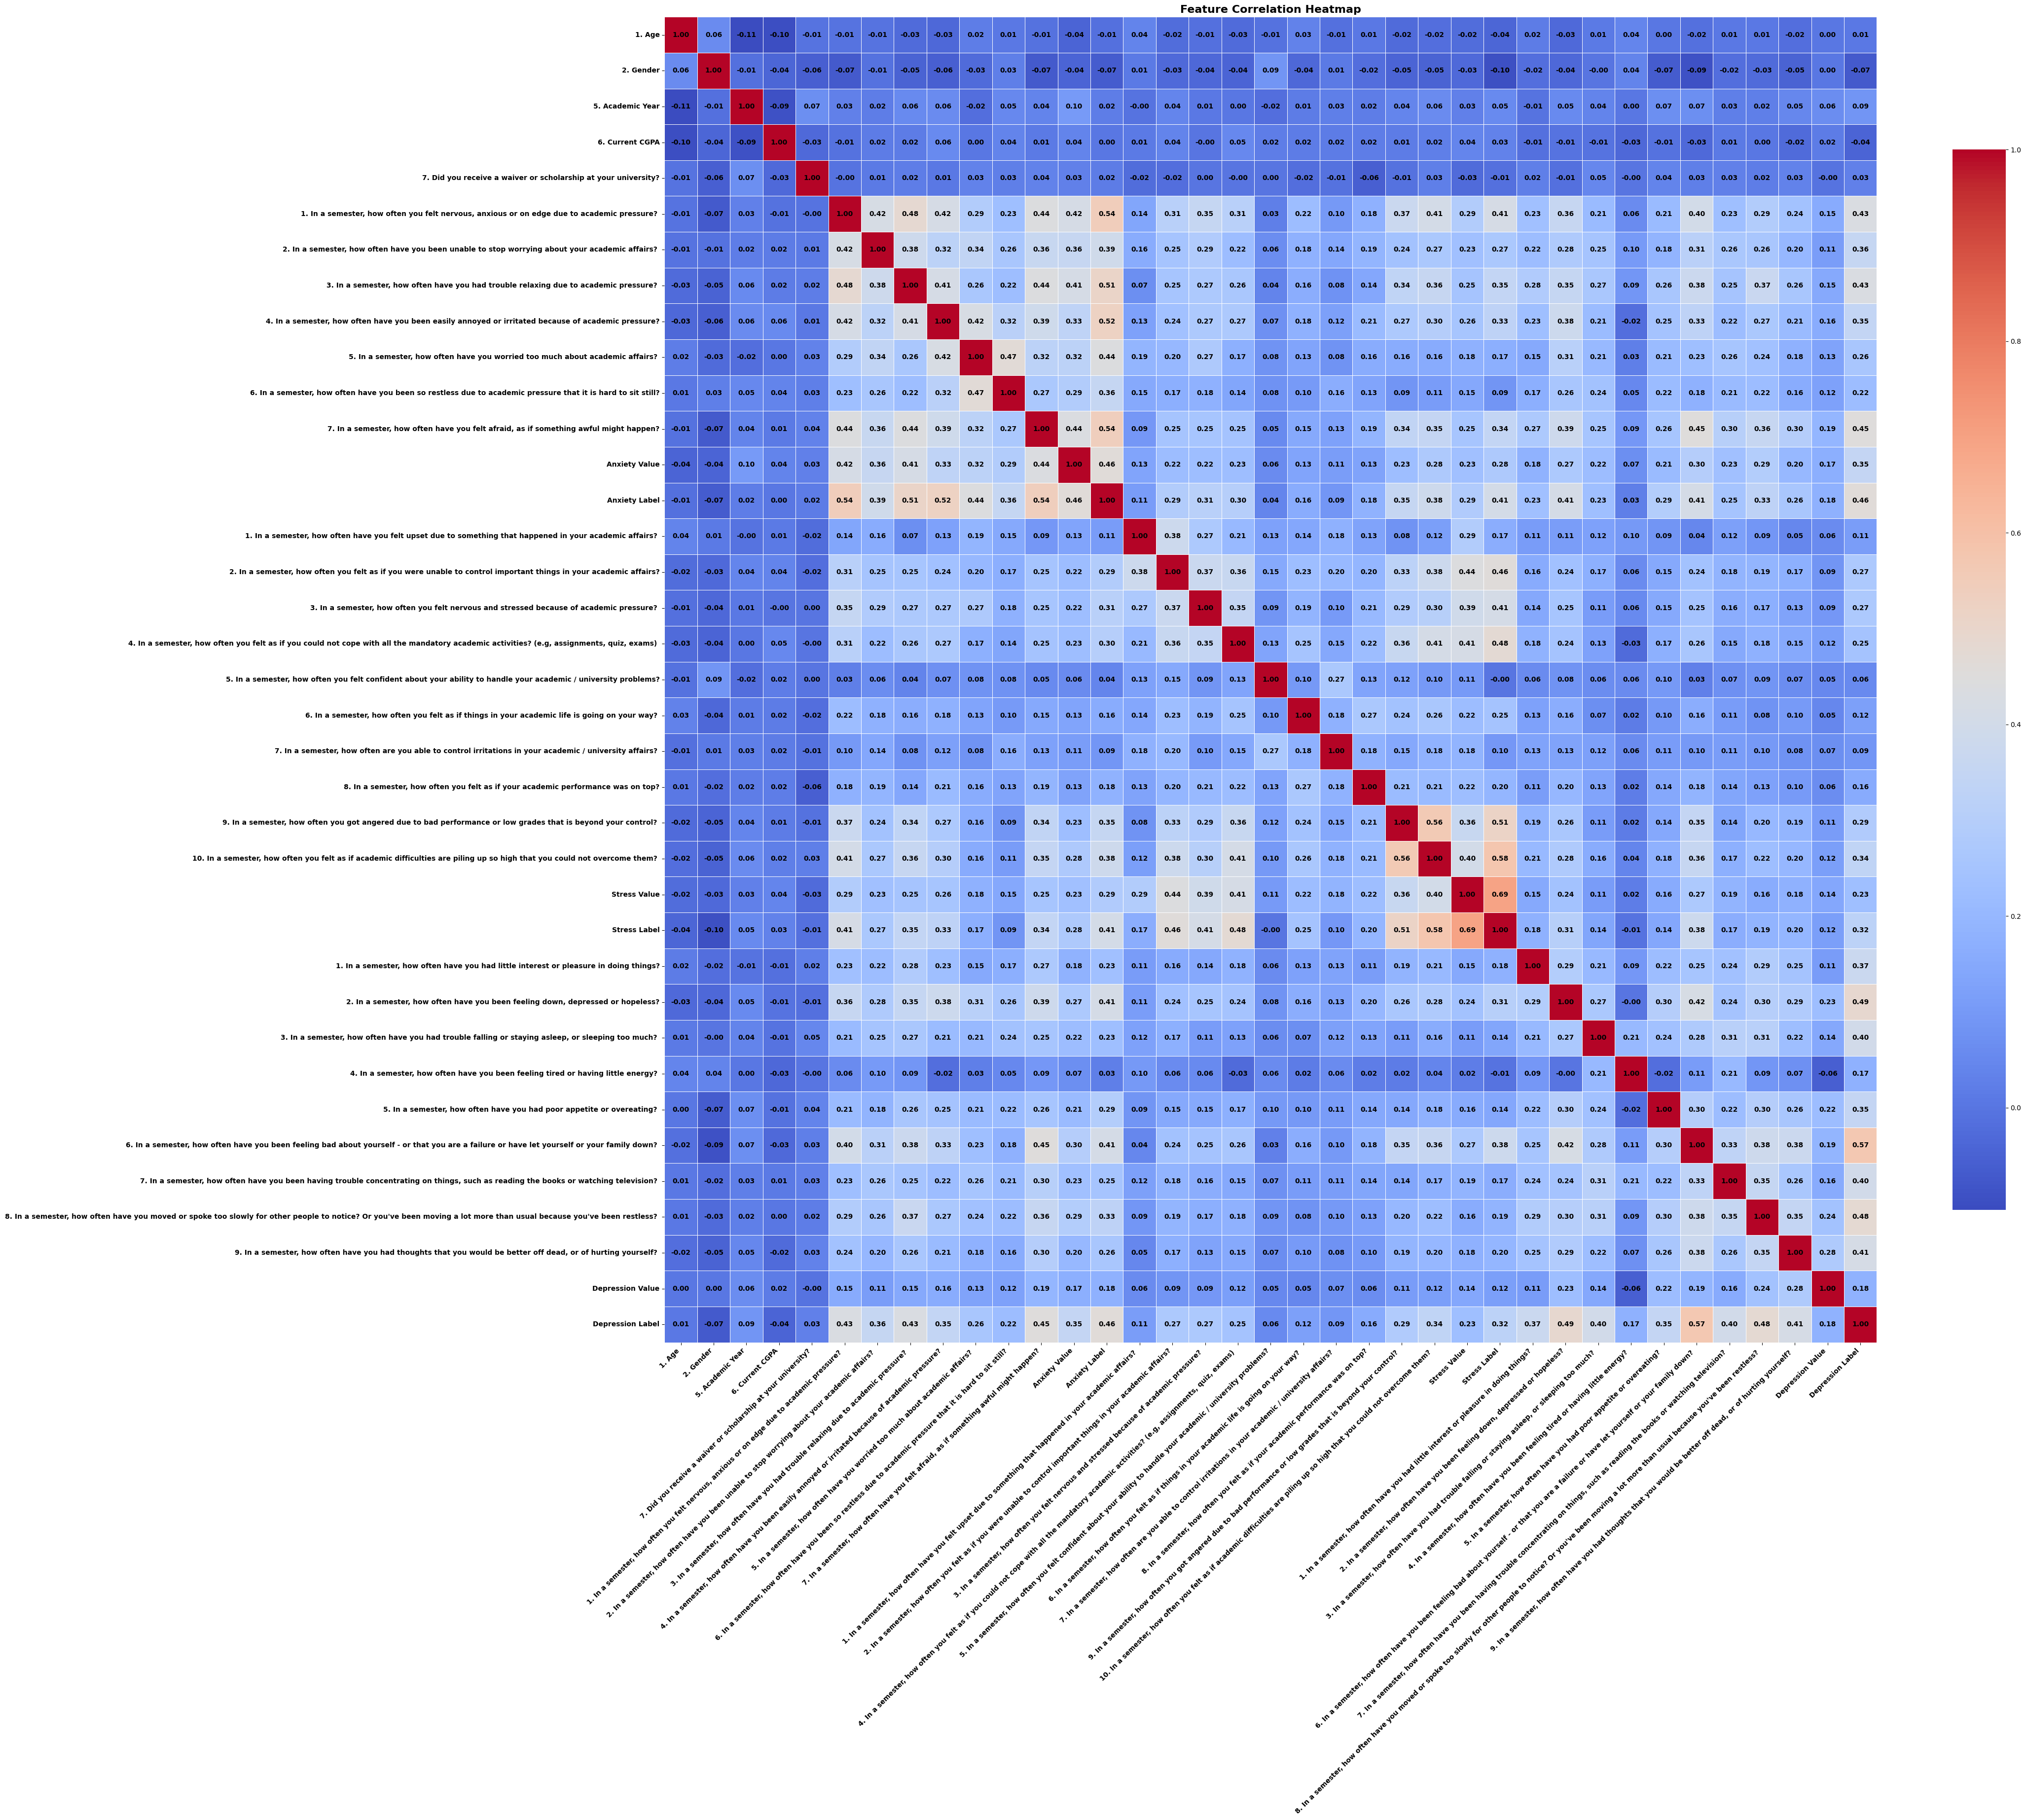

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encode labels temporarily for correlation
df_encoded = df.copy()
df_encoded = df_encoded.apply(lambda x: pd.factorize(x)[0])

# Increase figure size depending on number of features
num_features = len(df_encoded.columns)
plt.figure(figsize=(num_features*1.2, num_features*1))  # make bigger if many features

# Plot heatmap
sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=True,                     # show numbers
    fmt=".2f",                      # 2 decimal places
    annot_kws={"size":10, "weight":"bold", "color":"black"},
    linewidths=0.5,                 # grid lines
    cbar_kws={"shrink":0.8}         # shrink colorbar for readability
)

# Rotate x-axis labels so they do not overlap
plt.xticks(rotation=45, ha="right", fontsize=10, weight="bold")
plt.yticks(rotation=0, fontsize=10, weight="bold")

plt.title("Feature Correlation Heatmap", fontsize=16, weight="bold")
plt.tight_layout()  # adjust layout to prevent clipping
plt.show()



#8. Imbalanced Dataset Visualization

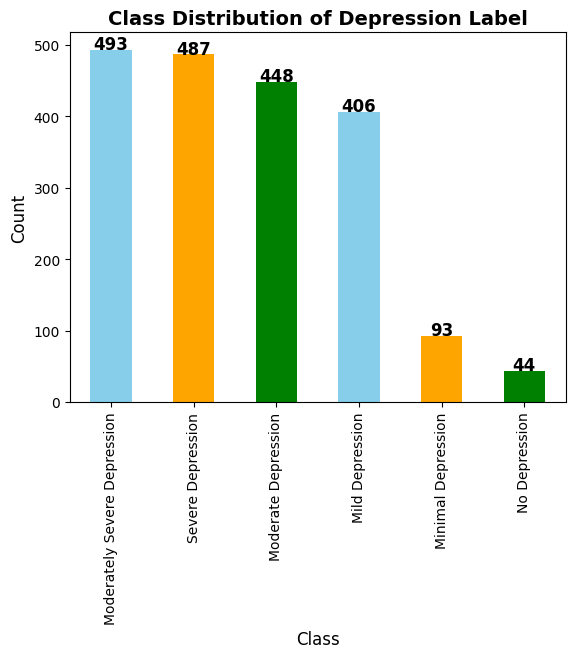

In [ ]:
import matplotlib.pyplot as plt

# Replace 'Depression Label' with the actual column name if different
target = df['Depression Label']

# Plot class distribution
ax = target.value_counts().plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title("Class Distribution of Depression Label", fontsize=14, weight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add counts on top of bars
for i, count in enumerate(target.value_counts()):
    ax.text(i, count + 1, str(count), ha='center', fontsize=12, weight='bold')

plt.show()




#9. Train-Test Split (Stratified)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,               # input features
    y,                      # output label
    test_size=0.20,         # 20% test data
    stratify=y,             # stratified split
    random_state=42
)

#10. Model Training & Testing

#KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)


#Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


#Neural Network (MLP)

In [ ]:
# Create MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

# Predict labels
y_pred_nn = mlp.predict(X_test)

# Predict probabilities for AUC/ROC
y_prob_nn = mlp.predict_proba(X_test)



#11. Model Evaluation Function

In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))


#12. Evaluate All Models

In [ ]:
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Neural Network", y_test, y_pred_nn)


KNN
Accuracy: 0.779746835443038
Precision: 0.7995469111611322
Recall: 0.779746835443038

Naive Bayes
Accuracy: 0.8556962025316456
Precision: 0.8611699559600958
Recall: 0.8556962025316456

Neural Network
Accuracy: 0.959493670886076
Precision: 0.9608077630811368
Recall: 0.959493670886076


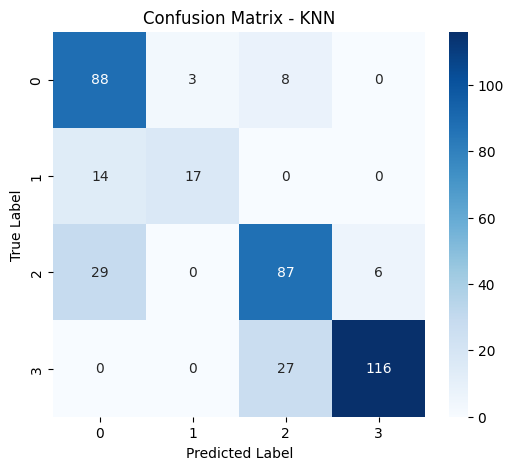

In [ ]:

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



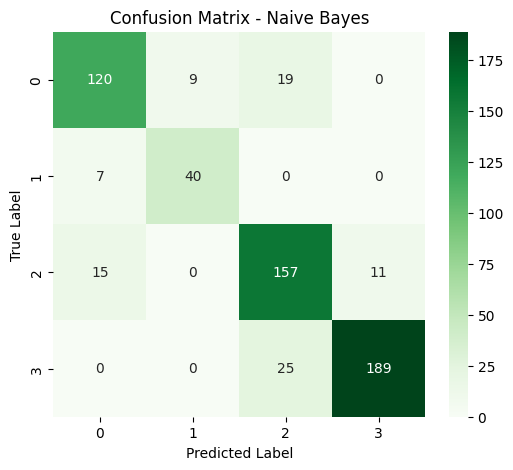

In [ ]:
# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

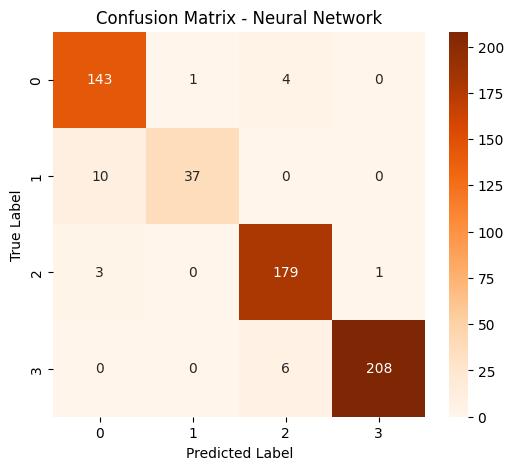

In [ ]:
# Neural Network Confusion Matrix
y_pred_mlp = mlp.predict(X_test)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#13. Accuracy Comparison Bar Chart

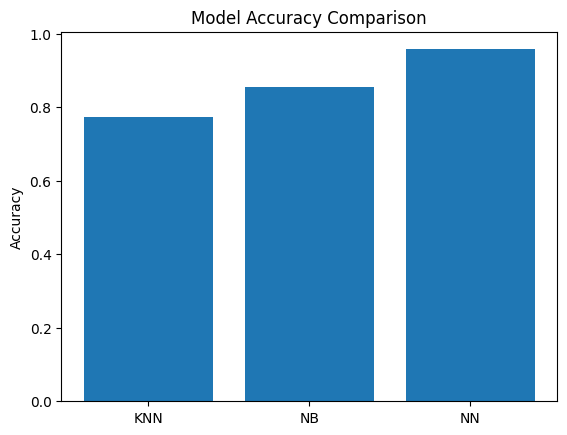

In [ ]:
models = ['KNN', 'NB', 'NN']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_nn)
]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


#14. ROC Curve

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)




In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
classes_dep = sorted(y.unique())


y_test_dep_bin = label_binarize(y_test, classes=classes_dep)



def plot_roc_auc(model, X_test, y_test_bin, classes, model_name):
    y_prob = model.predict_proba(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average AUC
    macro_auc = roc_auc_score(y_test_bin, y_prob, average="macro")

    # Plot ROC curves
    plt.figure(figsize=(7,5))
    for i in range(len(classes)):
        plt.plot(
            fpr[i],
            tpr[i],
            label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name} (Depression Label)")
    plt.legend()
    plt.show()

    return macro_auc



#KNN

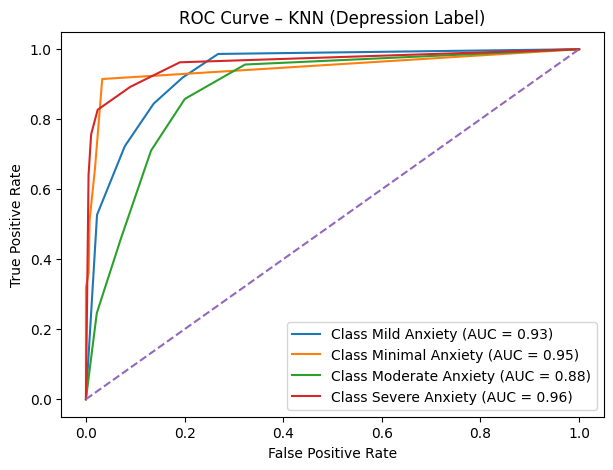

In [ ]:
dep_auc_knn = plot_roc_auc(
    knn,
    X_test,
    y_test_dep_bin,
    classes_dep,
    "KNN"
)


#Naive Bayes

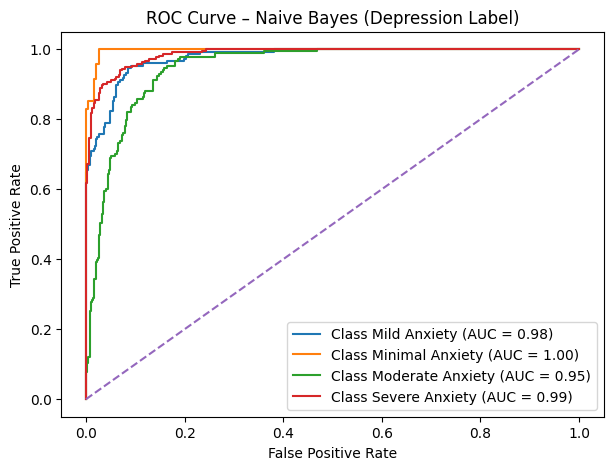

In [ ]:
nb_auc = plot_roc_auc(
    nb,
    X_test,
    y_test_dep_bin,     # or anxiety/stress binarized label
    classes_dep,
    "Naive Bayes"
)


#Neural Network

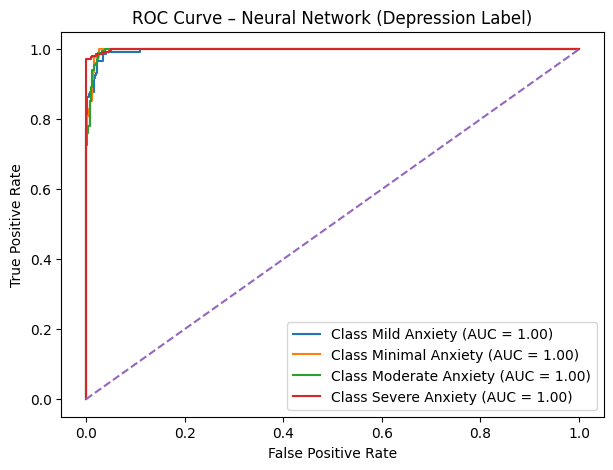

In [ ]:
dep_auc_mlp = plot_roc_auc(
    mlp,
    X_test,
    y_test_dep_bin,
    classes_dep,
    "Neural Network"
)



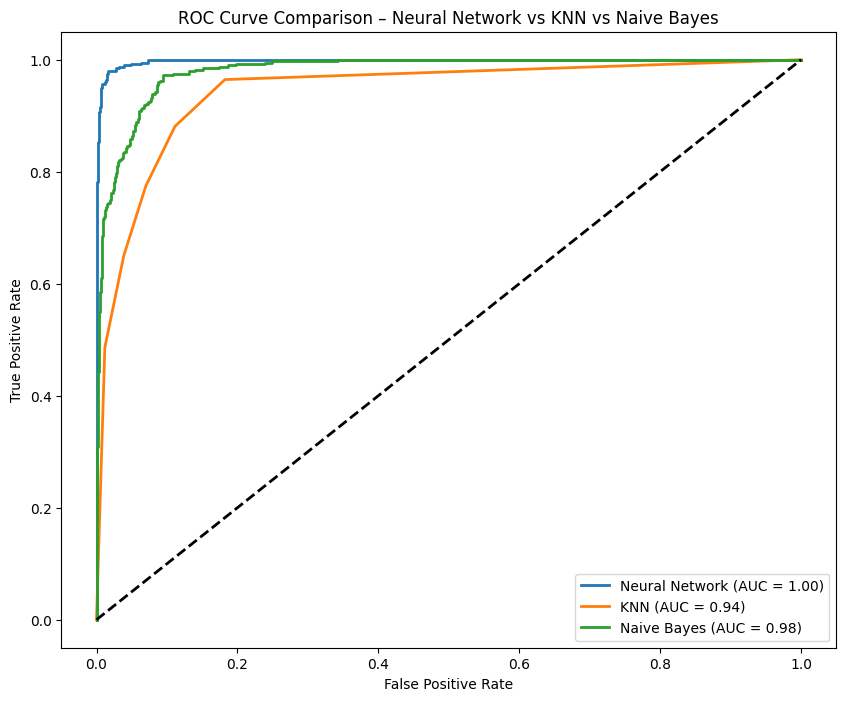

In [ ]:
# Ensure y_test is binarized for multiclass
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Function to plot ROC & return micro-average AUC
def plot_roc_auc(model, X_test, y_test_bin, model_name):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        raise ValueError(f"{model_name} does not have predict_proba.")

    # Compute micro-average ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
    return roc_auc

# =====================
# Create ROC Comparison Plot
# =====================
plt.figure(figsize=(10,8))

# Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
mlp_auc = plot_roc_auc(mlp, X_test, y_test_bin, "Neural Network")

# KNN
knn_auc = plot_roc_auc(knn, X_test, y_test_bin, "KNN")

# Naive Bayes
nb_auc = plot_roc_auc(nb, X_test, y_test_bin, "Naive Bayes")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], 'k--', lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – Neural Network vs KNN vs Naive Bayes")
plt.legend(loc='lower right')
plt.show()

In [ ]:
print(f"Neural Network AUC: {mlp_auc:.2f}")
print(f"KNN AUC: {knn_auc:.2f}")
print(f"Naive Bayes AUC: {nb_auc:.2f}")


Neural Network AUC: 1.00
KNN AUC: 0.94
Naive Bayes AUC: 0.98


#AUC comparison


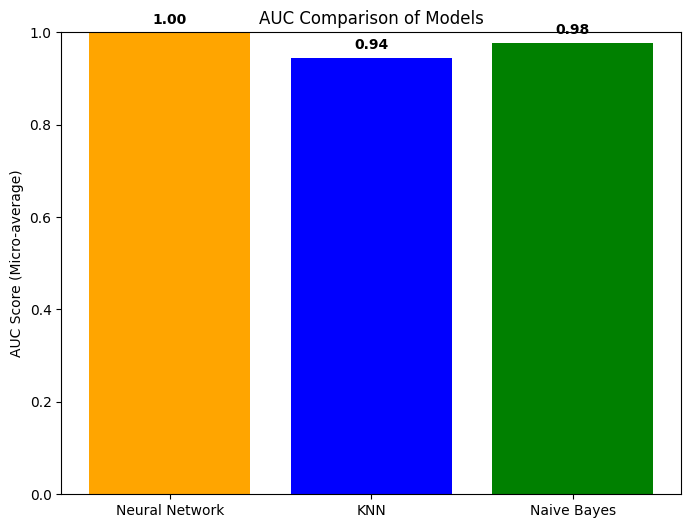

In [ ]:
models = ['Neural Network', 'KNN', 'Naive Bayes']
auc_scores = [mlp_auc, knn_auc, nb_auc]

plt.figure(figsize=(8,6))
plt.bar(models, auc_scores, color=['orange','blue','green'])
plt.ylim(0,1)
plt.ylabel('AUC Score (Micro-average)')
plt.title('AUC Comparison of Models')
for i, v in enumerate(auc_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

#15. K-Means Clustering (Unsupervised)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# 8.2 KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters



Explained Variance Ratio: [0.38237233 0.07508343]


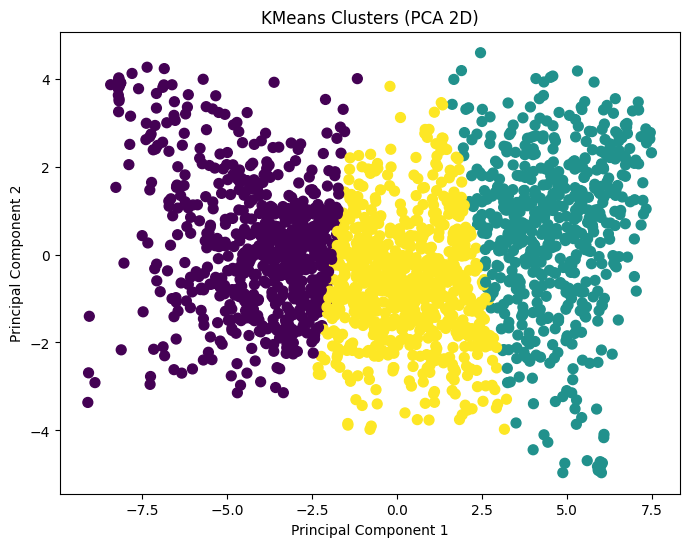

In [ ]:

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters (PCA 2D)")
plt.show()


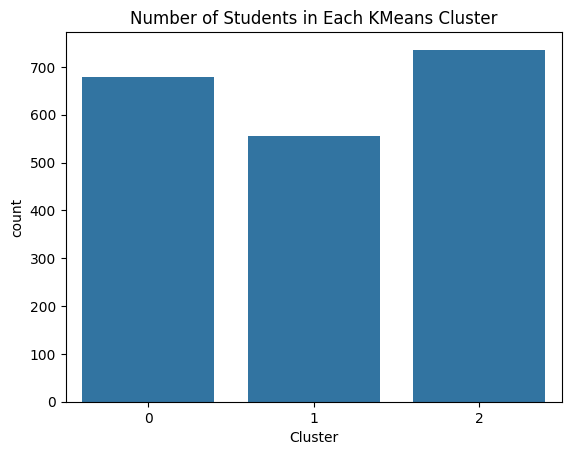

In [ ]:
#  Cluster Count
sns.countplot(x='Cluster', data=df)
plt.title("Number of Students in Each KMeans Cluster")
plt.show()